In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl xgboost

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [11]:
#Import Dataset
file_path = "C:/Users/ankur/Downloads/FastagFraudDetection.xlsx"

df = pd.read_excel(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (5000, 13)

Columns:
['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Vehicle_Plate_Number', 'Fraud_indicator']


,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator
0,1,2023-06-01 11:20:00,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud
1,2,2023-07-01 14:55:00,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud
2,3,2023-08-01 18:25:00,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud
3,4,2023-09-01 02:05:00,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud
4,5,2023-10-01 06:35:00,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud


In [12]:
#Data Inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Transaction_ID         5000 non-null   int64 
 1   Timestamp              5000 non-null   object
 2   Vehicle_Type           5000 non-null   object
 3   FastagID               4451 non-null   object
 4   TollBoothID            5000 non-null   object
 5   Lane_Type              5000 non-null   object
 6   Vehicle_Dimensions     5000 non-null   object
 7   Transaction_Amount     5000 non-null   int64 
 8   Amount_paid            5000 non-null   int64 
 9   Geographical_Location  5000 non-null   object
 10  Vehicle_Speed          5000 non-null   int64 
 11  Vehicle_Plate_Number   5000 non-null   object
 12  Fraud_indicator        5000 non-null   object
dtypes: int64(4), object(9)
memory usage: 507.9+ KB


In [10]:
#Check Misiing Values
missing = df.isnull().sum()

print(missing)

Transaction_ID             0
Timestamp                  0
Vehicle_Type               0
FastagID                 549
TollBoothID                0
Lane_Type                  0
Vehicle_Dimensions         0
Transaction_Amount         0
Amount_paid                0
Geographical_Location      0
Vehicle_Speed              0
Vehicle_Plate_Number       0
Fraud_indicator            0
dtype: int64


In [14]:
#Check duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
#check duplicate transaction IDs
print(
    "Duplicate Transaction IDs:",
    df["Transaction_ID"].duplicated().sum()
)

Duplicate Transaction IDs: 0


In [19]:
#Remove accidental whitespace
df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)

In [21]:
#Clean categorical/string columns
text_columns = df.select_dtypes(
    include=["object"]
).columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [23]:
#Standardize categorical values

#First inspect them:
categorical_columns = [
    "Vehicle_Type",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Dimensions",
    "Fraud_indicator"
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


Vehicle_Type:
Vehicle_Type
Bus           716
Car           714
Motorcycle    714
Truck         714
Van           714
Sedan         714
SUV           714
Name: count, dtype: int64

TollBoothID:
TollBoothID
B-102    1432
A-101    1428
C-103    1426
D-106     570
D-105     104
D-104      40
Name: count, dtype: int64

Lane_Type:
Lane_Type
Regular    2858
Express    2142
Name: count, dtype: int64

Vehicle_Dimensions:
Vehicle_Dimensions
Large     2144
Small     1428
Medium    1428
Name: count, dtype: int64

Fraud_indicator:
Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


In [24]:
#Convert Timestamp
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

print(df["Timestamp"].dtype)

datetime64[ns]


In [26]:
#Check numerical columns
numeric_columns = [
    "Transaction_Amount",
    "Amount_paid",
    "Vehicle_Speed"
]

print(df[numeric_columns].describe())

       Transaction_Amount  Amount_paid  Vehicle_Speed
count          5000.00000  5000.000000    5000.000000
mean            161.06200   141.261000      67.851200
std             112.44995   106.480996      16.597547
min               0.00000     0.000000      10.000000
25%             100.00000    90.000000      54.000000
50%             130.00000   120.000000      67.000000
75%             290.00000   160.000000      82.000000
max             350.00000   350.000000     118.000000


In [28]:
#impossible values
for col in numeric_columns:
    print(f"\n{col}")
    print("Negative:", (df[col] < 0).sum())
    print("Zero:", (df[col] == 0).sum())


Transaction_Amount
Negative: 0
Zero: 714

Amount_paid
Negative: 0
Zero: 788

Vehicle_Speed
Negative: 0
Zero: 0


In [29]:
#Validate payment amounts
invalid_payment = df[
    df["Amount_paid"] > df["Transaction_Amount"]
]

print(
    "Amount paid greater than transaction amount:",
    len(invalid_payment)
)

Amount paid greater than transaction amount: 24


In [31]:
#Check geographical data
location_split = df[
    "Geographical_Location"
].str.split(",", expand=True)

print(location_split.shape)

df["Latitude"] = pd.to_numeric(
    location_split[0],
    errors="coerce"
)

df["Longitude"] = pd.to_numeric(
    location_split[1],
    errors="coerce"
)

(5000, 2)


In [33]:
#Validate geographic ranges
invalid_coordinates = df[
    (df["Latitude"] < -90) |
    (df["Latitude"] > 90) |
    (df["Longitude"] < -180) |
    (df["Longitude"] > 180)
]

print(
    "Invalid coordinates:",
    len(invalid_coordinates)
)

Invalid coordinates: 0


In [35]:
#Check the target
print(df["Fraud_indicator"].value_counts(dropna=False))

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64


In [37]:
#Check for unexpected labels
print(
    df["Fraud_indicator"].unique()
)

['Fraud' 'Not Fraud']


In [39]:
#Final cleaning report
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (5000, 15)

Missing values:
Transaction_ID              0
Timestamp                1959
Vehicle_Type                0
FastagID                  549
TollBoothID                 0
Lane_Type                   0
Vehicle_Dimensions          0
Transaction_Amount          0
Amount_paid                 0
Geographical_Location       0
Vehicle_Speed               0
Vehicle_Plate_Number        0
Fraud_indicator             0
Latitude                    0
Longitude                   0
dtype: int64

Duplicate rows:
0

Data types:
Transaction_ID                    int64
Timestamp                datetime64[ns]
Vehicle_Type                     object
FastagID                         object
TollBoothID                      object
Lane_Type                        object
Vehicle_Dimensions               object
Transaction_Amount                int64
Amount_paid                       int64
Geographical_Location            object
Vehicle_Speed                     int64
Vehicle_Plate_Number          

In [41]:
df.to_excel(
    "FastagFraudDetection_Cleaned.xlsx",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [43]:
from IPython.display import FileLink

FileLink("FastagFraudDetection_Cleaned.xlsx")

C:\Users\ankur\FastagFraudDetection_Cleaned.xlsx

In [45]:
!pip install geopy

In [4]:
import pandas as pd
import time
from geopy.geocoders import Nominatim

# Load cleaned data
df = pd.read_excel("FastagFraudDetection_Cleaned.xlsx")

# Get unique coordinates
coords = (
    df[["Latitude", "Longitude"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Total transactions:", len(df))
print("Unique coordinates:", len(coords))

Total transactions: 5000
Unique coordinates: 5


In [5]:
geolocator = Nominatim(
    user_agent="fastag_fraud_project_ankur"
)

location_cache = {}

for i, row in coords.iterrows():

    lat = row["Latitude"]
    lon = row["Longitude"]

    key = (lat, lon)

    if key in location_cache:
        continue

    try:
        location = geolocator.reverse(
            (lat, lon),
            exactly_one=True,
            language="en",
            zoom=10
        )

        if location:
            address = location.raw.get("address", {})

            location_cache[key] = {
                "Real_Geographical_Location": location.address,
                "City": (
                    address.get("city")
                    or address.get("town")
                    or address.get("village")
                    or address.get("municipality")
                ),
                "State": address.get("state"),
                "Country": address.get("country")
            }
        else:
            location_cache[key] = {
                "Real_Geographical_Location": None,
                "City": None,
                "State": None,
                "Country": None
            }

    except Exception:
        location_cache[key] = {
            "Real_Geographical_Location": None,
            "City": None,
            "State": None,
            "Country": None
        }

    # Nominatim usage policy requires a delay
    time.sleep(1)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(coords)} coordinates")

In [6]:
location_df = pd.DataFrame(
    [
        {
            "Latitude": lat,
            "Longitude": lon,
            **details
        }
        for (lat, lon), details in location_cache.items()
    ]
)

location_df.head()

,Latitude,Longitude,Real_Geographical_Location,City,State,Country
0,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India
1,13.042661,77.475801,"Bangalore North, Bengaluru Urban, Karnataka, I...",None,Karnataka,India
2,12.841977,77.675475,"Anekal, Bengaluru Urban, Karnataka, India",None,Karnataka,India
3,12.936687,77.531140,"Bengaluru West City Corporation, Bengaluru, Ba...",Bengaluru,Karnataka,India
4,13.213316,77.554135,"Yelahanka taluku, Bengaluru Urban, Karnataka, ...",None,Karnataka,India


In [7]:
df = df.merge(
    location_df,
    on=["Latitude", "Longitude"],
    how="left"
)

In [8]:
output_file = "FastagFraudDetection_Cleaned_Geocoded.xlsx"

df.to_excel(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: FastagFraudDetection_Cleaned_Geocoded.xlsx


In [9]:
from IPython.display import FileLink

FileLink("FastagFraudDetection_Cleaned.xlsx")

C:\Users\ankur\FastagFraudDetection_Cleaned.xlsx

In [10]:
df.head()

,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,Vehicle_Speed,Vehicle_Plate_Number,Fraud_indicator,Latitude,Longitude,Real_Geographical_Location,City,State,Country
0,1,NaT,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",65,KA11AB1234,Fraud,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India
1,2,NaT,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",78,KA66CD5678,Fraud,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India
2,3,NaT,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",53,KA88EF9012,Not Fraud,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India
3,4,NaT,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",92,KA11GH3456,Fraud,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India
4,5,NaT,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",60,KA44IJ6789,Fraud,13.059816,77.770687,"Hosakote taluk, Bengaluru North, Karnataka, India",None,Karnataka,India


In [11]:
from IPython.display import FileLink

FileLink("FastagFraudDetection_Cleaned_With_Location.xlsx")

C:\Users\ankur\FastagFraudDetection_Cleaned_With_Location.xlsx

In [12]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\ankur

Files in this folder:
['.accessibility.properties', '.anaconda', '.bash_history', '.cache', '.chocolatey', '.claude', '.claude.json', '.codex', '.conda', '.condarc', '.config', '.continuum', '.docker', '.expo', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.matplotlib', '.ms-ad', '.n8n', '.Neo4jDesktop2', '.node_repl_history', '.ollama', '.openclaw', '.sbx-denybin', '.virtual_documents', '.vscode', '.vscode-shared', '.wdm', 'amazon_cleaned.csv', 'anaconda3', 'android_traffic_transformed.csv', 'ansel', 'AppData', 'Application Data', 'Automind.ipynb', 'Books MBA DSDA 1', 'cardekho_vehicle_urls.csv', 'Class 2.ipynb', 'cleaned_analyzed_output.xlsx', 'Cleaned_Finance_Data.csv', 'Contacts', 'Cookies', 'dataset', 'data_clean.ipynb', 'Data_collection.ipynb', 'DL_DrowsinessModel1.ipynb', 'Documents', 'Downloads', 'DXB_MCT_forecast.xlsx', 'Exploratory_data_analysis.ipynb', 'Fastag Fraud.ipynb', 'FastagFraudDetection_Cleaned.xls

In [13]:
output_file = "FastagFraudDetection_Cleaned_With_Location.xlsx"

df_final.to_excel(
    output_file,
    index=False
)

print("File created successfully!")
print(os.path.abspath(output_file))

NameError: name 'df_final' is not defined

In [14]:
print("df exists:", "df" in globals())
print("location_df exists:", "location_df" in globals())
print("df_final exists:", "df_final" in globals())

df exists: True
location_df exists: True
df_final exists: False


In [15]:
df_final = df.merge(
    location_df,
    on=["Latitude", "Longitude"],
    how="left"
)

print(df_final.shape)
print(
    df_final[
        ["Latitude", "Longitude",
         "Real_Geographical_Location",
         "City", "State", "Country"]
    ].head()
)

(5000, 23)


KeyError: "['Real_Geographical_Location', 'City', 'State', 'Country'] not in index"

In [16]:
print("df_final columns:")
print(df_final.columns.tolist())

print("\nlocation_df columns:")
print(location_df.columns.tolist())

df_final columns:
['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Vehicle_Plate_Number', 'Fraud_indicator', 'Latitude', 'Longitude', 'Real_Geographical_Location_x', 'City_x', 'State_x', 'Country_x', 'Real_Geographical_Location_y', 'City_y', 'State_y', 'Country_y']

location_df columns:
['Latitude', 'Longitude', 'Real_Geographical_Location', 'City', 'State', 'Country']


In [17]:
import pandas as pd
import requests
import time

# Make sure we are working with the cleaned dataframe
df = pd.read_excel("FastagFraudDetection_Cleaned.xlsx")

# Get unique coordinates
unique_coords = (
    df[["Latitude", "Longitude"]]
    .dropna()
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Unique coordinates:", len(unique_coords))


def reverse_geocode(lat, lon):

    url = "https://nominatim.openstreetmap.org/reverse"

    params = {
        "lat": float(lat),
        "lon": float(lon),
        "format": "json",
        "zoom": 18,
        "addressdetails": 1
    }

    headers = {
        "User-Agent": "FASTAG-Fraud-Detection-Project/1.0"
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=15
        )

        print("Status:", response.status_code)

        if response.status_code != 200:
            return {
                "Real_Geographical_Location": None,
                "City": None,
                "District": None,
                "State": None,
                "Country": None,
                "Postal_Code": None
            }

        data = response.json()

        address = data.get("address", {})

        city = (
            address.get("city")
            or address.get("town")
            or address.get("village")
            or address.get("municipality")
            or address.get("suburb")
        )

        return {
            "Real_Geographical_Location":
                data.get("display_name"),

            "City":
                city,

            "District":
                address.get("county"),

            "State":
                address.get("state"),

            "Country":
                address.get("country"),

            "Postal_Code":
                address.get("postcode")
        }

    except Exception as e:

        print("Error:", e)

        return {
            "Real_Geographical_Location": None,
            "City": None,
            "District": None,
            "State": None,
            "Country": None,
            "Postal_Code": None
        }


# Reverse geocode unique coordinates
location_results = []

for i, row in unique_coords.iterrows():

    print(
        f"\nProcessing {i+1}/{len(unique_coords)}"
    )

    result = reverse_geocode(
        row["Latitude"],
        row["Longitude"]
    )

    result["Latitude"] = row["Latitude"]
    result["Longitude"] = row["Longitude"]

    location_results.append(result)

    # Respect Nominatim rate limit
    time.sleep(1)


# Create location lookup dataframe
location_df = pd.DataFrame(location_results)

print("\nLOCATION DATA:")
display(location_df)

Unique coordinates: 5

Processing 1/5
Status: 200

Processing 2/5
Status: 200

Processing 3/5
Status: 200

Processing 4/5
Status: 200

Processing 5/5
Status: 200

LOCATION DATA:


,Real_Geographical_Location,City,District,State,Country,Postal_Code,Latitude,Longitude
0,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114,13.059816,77.770687
1,"Madhavara, Chikkabidarakallu, Bangalore North,...",Chikkabidarakallu,Bangalore North,Karnataka,India,560073,13.042661,77.475801
2,"Bangalore Elevated Tollways Limited, Electroni...",Electronic City,Anekal,Karnataka,India,560100,12.841977,77.675475
3,"NICE Expressway, Pramodha Layout, Bangarappa N...",Bengaluru,Bangalore South,Karnataka,India,560039,12.936687,77.531140
4,"Doddaballapur Road, Kadathanamale, Suradenapur...",Suradenapura,Yelahanka taluku,Karnataka,India,560064,13.213316,77.554135


In [18]:
df_final = df.merge(
    location_df,
    on=["Latitude", "Longitude"],
    how="left"
)

print("Final shape:", df_final.shape)

display(
    df_final[
        [
            "Latitude",
            "Longitude",
            "Real_Geographical_Location",
            "City",
            "District",
            "State",
            "Country",
            "Postal_Code"
        ]
    ].head(10)
)

Final shape: (5000, 21)


,Latitude,Longitude,Real_Geographical_Location,City,District,State,Country,Postal_Code
0,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
1,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
2,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
3,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
4,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
5,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
6,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
7,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
8,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
9,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114


In [19]:
output_file = "FastagFraudDetection_Cleaned_With_Location.xlsx"

df_final.to_excel(
    output_file,
    index=False
)

print("File created successfully!")

File created successfully!


In [20]:
import os

print(os.path.exists(output_file))
print(os.path.abspath(output_file))

True
C:\Users\ankur\FastagFraudDetection_Cleaned_With_Location.xlsx


In [21]:
from IPython.display import FileLink

FileLink(output_file)

C:\Users\ankur\FastagFraudDetection_Cleaned_With_Location.xlsx

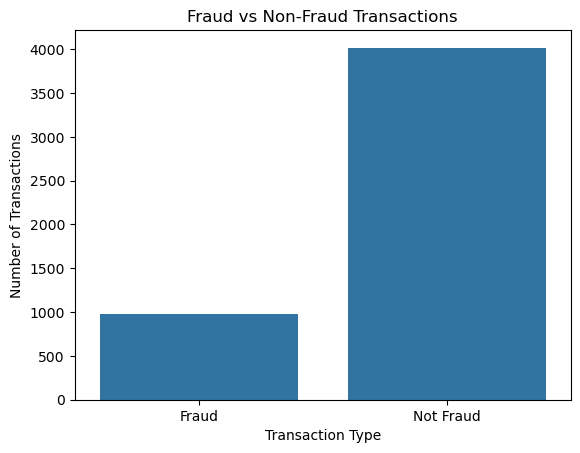

In [23]:
#Fraud Distribution

#Question: How prevalent is fraud?

#Analyze:

#Fraud vs Not Fraud count
#Fraud percentage
#Class imbalance
#Why important: Establishes your target variable and tells you whether class imbalance needs to be considered.

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Fraud_indicator")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

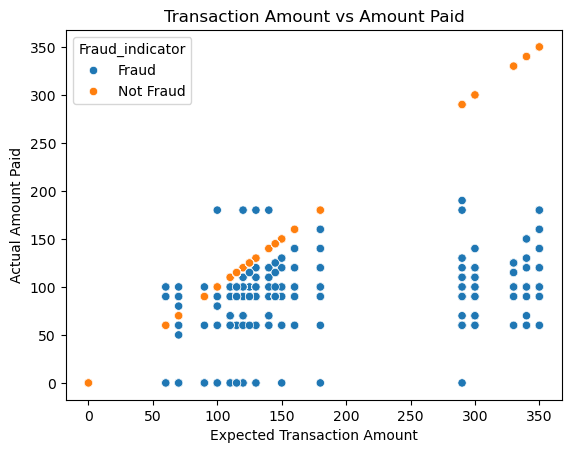

In [24]:
#Transaction Amount vs Amount Paid

#Question: Are fraudulent transactions associated with payment discrepancies?

sns.scatterplot(
    data=df,
    x="Transaction_Amount",
    y="Amount_paid",
    hue="Fraud_indicator"
)

plt.title("Transaction Amount vs Amount Paid")
plt.xlabel("Expected Transaction Amount")
plt.ylabel("Actual Amount Paid")
plt.show()

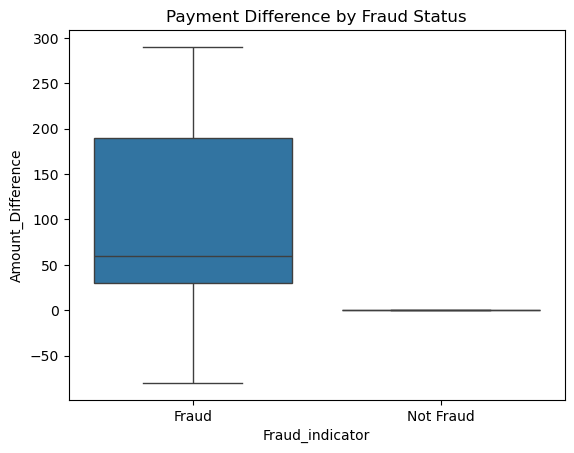

In [25]:
df["Amount_Difference"] = (
    df["Transaction_Amount"] -
    df["Amount_paid"]
)

sns.boxplot(
    data=df,
    x="Fraud_indicator",
    y="Amount_Difference"
)

plt.title("Payment Difference by Fraud Status")
plt.show()

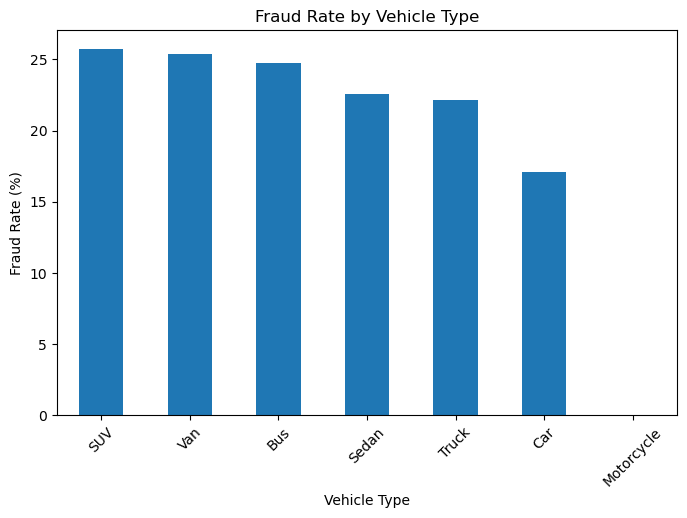

In [26]:
#Fraud Rate by Vehicle Type

#Because motorcycles legitimately have ₹0 toll, this analysis is particularly important.

fraud_rate = (
    df.groupby("Vehicle_Type")["Fraud_indicator"]
      .apply(lambda x: (x == "Fraud").mean() * 100)
      .sort_values(ascending=False)
)

fraud_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Vehicle Type")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Vehicle Type")
plt.xticks(rotation=45)
plt.show()

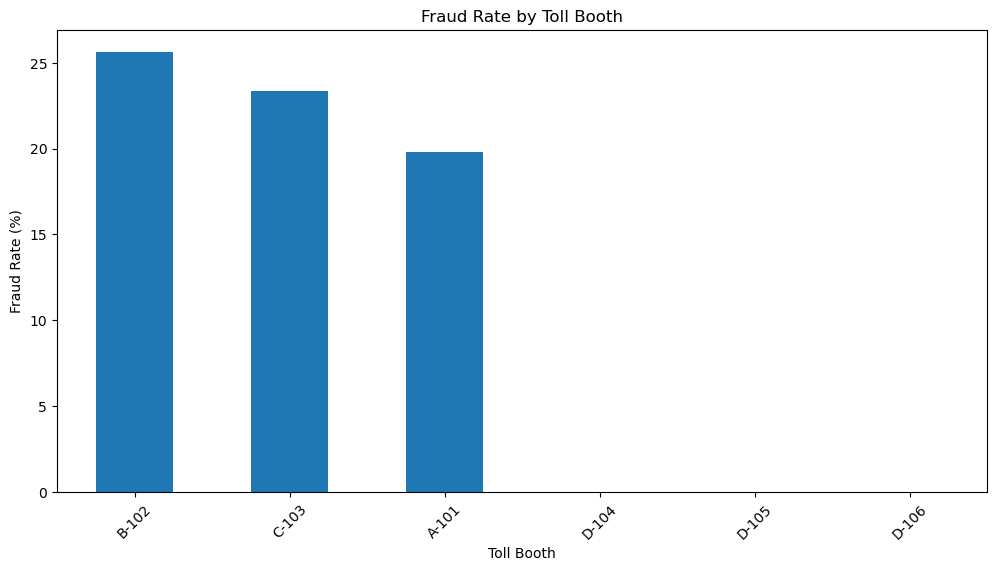

In [58]:
#Fraud Rate by Toll Booth

#Question: Are fraudulent transactions geographically concentrated around particular toll booths?

booth_fraud = (
    df.groupby("TollBoothID")["Fraud_indicator"]
      .apply(lambda x: (x == "Fraud").mean() * 100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

booth_fraud.plot(kind="bar")

plt.title("Fraud Rate by Toll Booth")
plt.xlabel("Toll Booth")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [32]:
fraud_rate = (
    df.groupby("Vehicle_Type")["Fraud_indicator"]
      .apply(lambda x: (x == "Fraud").mean() * 100)
      .sort_values(ascending=False)
)

print(fraud_rate)

df.groupby("Lane_Type")["Fraud_indicator"] \
  .apply(lambda x: (x == "Fraud").mean() * 100)

df.groupby("Vehicle_Dimensions")["Fraud_indicator"] \
  .apply(lambda x: (x == "Fraud").mean() * 100)

df.groupby("TollBoothID")["Fraud_indicator"] \
  .apply(lambda x: (x == "Fraud").mean() * 100)

Vehicle_Type
SUV           25.770308
Van           25.350140
Bus           24.720670
Sedan         22.549020
Truck         22.128852
Car           17.086835
Motorcycle     0.000000
Name: Fraud_indicator, dtype: float64


TollBoothID
A-101    19.817927
B-102    25.628492
C-103    23.352034
D-104     0.000000
D-105     0.000000
D-106     0.000000
Name: Fraud_indicator, dtype: float64

In [33]:
df["Fraud_Label"] = (
    df["Fraud_indicator"] == "Fraud"
).astype(int)

In [34]:
numeric_cols = [
    "Transaction_Amount",
    "Amount_paid",
    "Vehicle_Speed",
    "Latitude",
    "Longitude",
    "Fraud_Label"
]

correlation = df[numeric_cols].corr()

print(correlation["Fraud_Label"].sort_values(
    ascending=False
))

Fraud_Label           1.000000
Transaction_Amount    0.142957
Longitude             0.072250
Vehicle_Speed         0.014594
Latitude             -0.051762
Amount_paid          -0.224981
Name: Fraud_Label, dtype: float64


In [35]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Categorical variables
categorical_cols = [
    "Vehicle_Type",
    "Lane_Type",
    "Vehicle_Dimensions",
    "TollBoothID"
]

# Function to calculate Cramér's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    
    phi2 = chi2 / n
    
    # Bias correction
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(
        phi2corr / min(kcorr - 1, rcorr - 1)
    )


results = []

for col in categorical_cols:

    # Create contingency table
    table = pd.crosstab(
        df[col],
        df["Fraud_indicator"]
    )

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(table)

    # Cramér's V
    v = cramers_v(table.values)

    results.append({
        "Variable": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramers_V": v
    })


# Create results dataframe
categorical_correlation = pd.DataFrame(results)

# Sort by strength of association
categorical_correlation = categorical_correlation.sort_values(
    "Cramers_V",
    ascending=False
)

categorical_correlation

,Variable,Chi-Square,p-value,Cramers_V
0,Vehicle_Type,227.367566,2.791048e-46,0.210433
3,TollBoothID,219.348607,2.048814e-45,0.207070
2,Vehicle_Dimensions,156.427800,1.076799e-34,0.175760
1,Lane_Type,24.180581,8.771224e-07,0.068096


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [37]:
df = pd.read_excel("C:/Users/ankur/Downloads/FastagFraudDetection_Cleaned_With_Location.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 21)


,Transaction_ID,Timestamp,Vehicle_Type,FastagID,TollBoothID,Lane_Type,Vehicle_Dimensions,Transaction_Amount,Amount_paid,Geographical_Location,...,Vehicle_Plate_Number,Fraud_indicator,Latitude,Longitude,Real_Geographical_Location,City,District,State,Country,Postal_Code
0,1,NaT,Bus,FTG-001-ABC-121,A-101,Express,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11AB1234,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
1,2,NaT,Car,FTG-002-XYZ-451,B-102,Regular,Small,120,100,"13.059816123454882, 77.77068662374292",...,KA66CD5678,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
2,3,NaT,Motorcycle,NaN,D-104,Regular,Small,0,0,"13.059816123454882, 77.77068662374292",...,KA88EF9012,Not Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
3,4,NaT,Truck,FTG-044-LMN-322,C-103,Regular,Large,350,120,"13.059816123454882, 77.77068662374292",...,KA11GH3456,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114
4,5,NaT,Van,FTG-505-DEF-652,B-102,Express,Medium,140,100,"13.059816123454882, 77.77068662374292",...,KA44IJ6789,Fraud,13.059816,77.770687,"Old Madras Road, Toll Plaza, Hoskote, Hosakote...",Hoskote,Hosakote taluk,Karnataka,India,562114


In [38]:
print(df.columns.tolist())

['Transaction_ID', 'Timestamp', 'Vehicle_Type', 'FastagID', 'TollBoothID', 'Lane_Type', 'Vehicle_Dimensions', 'Transaction_Amount', 'Amount_paid', 'Geographical_Location', 'Vehicle_Speed', 'Vehicle_Plate_Number', 'Fraud_indicator', 'Latitude', 'Longitude', 'Real_Geographical_Location', 'City', 'District', 'State', 'Country', 'Postal_Code']


In [39]:
print(df["Fraud_indicator"].value_counts())

print("\nPercentage:")
print(
    df["Fraud_indicator"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Fraud_indicator
Not Fraud    4017
Fraud         983
Name: count, dtype: int64

Percentage:
Fraud_indicator
Not Fraud    80.34
Fraud        19.66
Name: proportion, dtype: float64


In [40]:
df["Fraud_Label"] = (
    df["Fraud_indicator"]
    .str.strip()
    .str.lower()
    .eq("fraud")
    .astype(int)
)

print(df["Fraud_Label"].value_counts())

Fraud_Label
0    4017
1     983
Name: count, dtype: int64


In [41]:
df["Amount_Difference"] = (
    df["Amount_paid"] - df["Transaction_Amount"]
)

In [42]:
df["Payment_Ratio"] = np.where(
    df["Transaction_Amount"] > 0,
    df["Amount_paid"] / df["Transaction_Amount"],
    1
)

In [43]:
df["Payment_Mismatch"] = (
    df["Amount_Difference"] != 0
).astype(int)

print(df["Payment_Mismatch"].value_counts())

Payment_Mismatch
0    4017
1     983
Name: count, dtype: int64


In [44]:
features = [
    "Vehicle_Type",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Dimensions",
    "Transaction_Amount",
    "Amount_paid",
    "Vehicle_Speed",
    "Latitude",
    "Longitude"
]

X = df[features]
y = df["Fraud_Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 9)
y shape: (5000,)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (4000, 9)
Testing set : (1000, 9)

Training target distribution:
Fraud_Label
0    0.8035
1    0.1965
Name: proportion, dtype: float64

Testing target distribution:
Fraud_Label
0    0.803
1    0.197
Name: proportion, dtype: float64


In [46]:
categorical_features = [
    "Vehicle_Type",
    "TollBoothID",
    "Lane_Type",
    "Vehicle_Dimensions"
]

numerical_features = [
    "Transaction_Amount",
    "Amount_paid",
    "Vehicle_Speed",
    "Latitude",
    "Longitude"
]

In [47]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [48]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [49]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [50]:
!pip install xgboost

In [51]:
from xgboost import XGBClassifier

print("XGBoost imported successfully")

XGBoost imported successfully


In [52]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative class:", negative)
print("Positive class:", positive)
print("Scale pos weight:", scale_pos_weight)

Negative class: 3214
Positive class: 786
Scale pos weight: 4.089058524173028


In [53]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully")

XGBoost trained successfully


In [54]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of Fraud
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.980,0.9944,0.9036,0.9468,0.9876,0.9834
1,Random Forest,0.993,1.0000,0.9645,0.9819,0.9998,0.9993
2,XGBoost,0.998,1.0000,0.9898,0.9949,1.0000,1.0000


In [55]:
for name, model in models.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    y_pred = model.predict(X_test)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Not Fraud", "Fraud"]
        )
    )


Logistic Regression
              precision    recall  f1-score   support

   Not Fraud       0.98      1.00      0.99       803
       Fraud       0.99      0.90      0.95       197

    accuracy                           0.98      1000
   macro avg       0.99      0.95      0.97      1000
weighted avg       0.98      0.98      0.98      1000


Random Forest
              precision    recall  f1-score   support

   Not Fraud       0.99      1.00      1.00       803
       Fraud       1.00      0.96      0.98       197

    accuracy                           0.99      1000
   macro avg       1.00      0.98      0.99      1000
weighted avg       0.99      0.99      0.99      1000


XGBoost
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00       803
       Fraud       1.00      0.99      0.99       197

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      

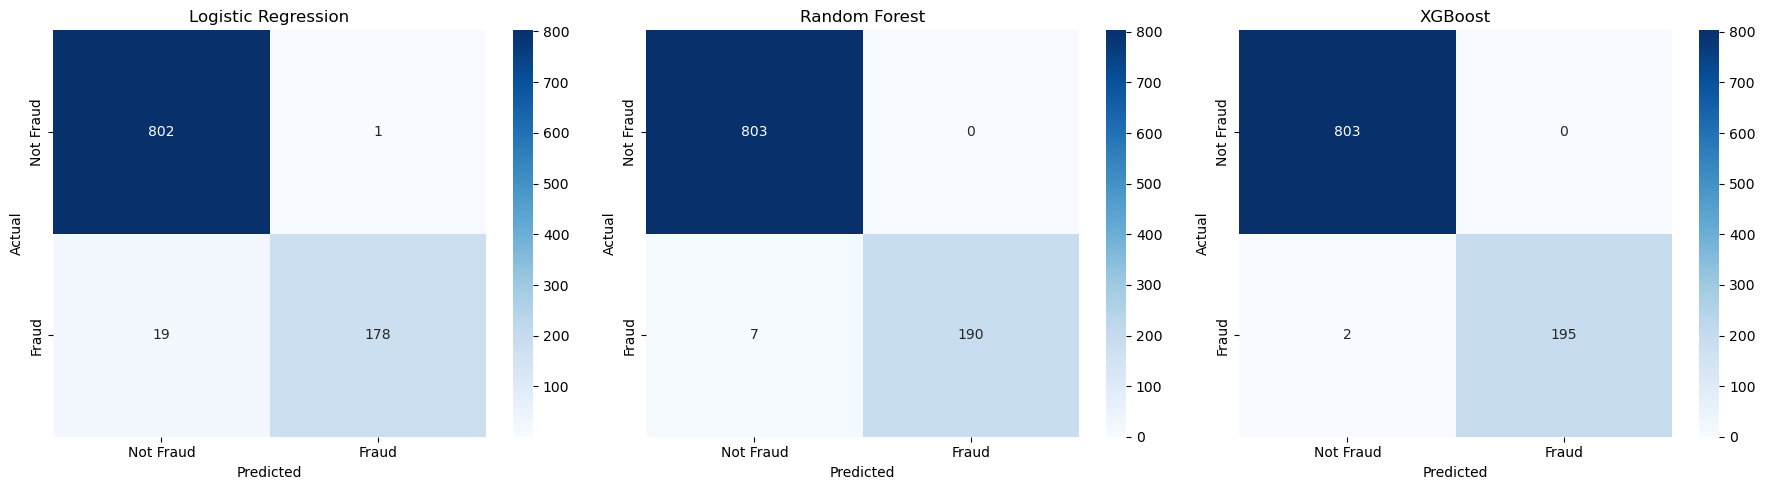

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Not Fraud", "Fraud"],
        yticklabels=["Not Fraud", "Fraud"]
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

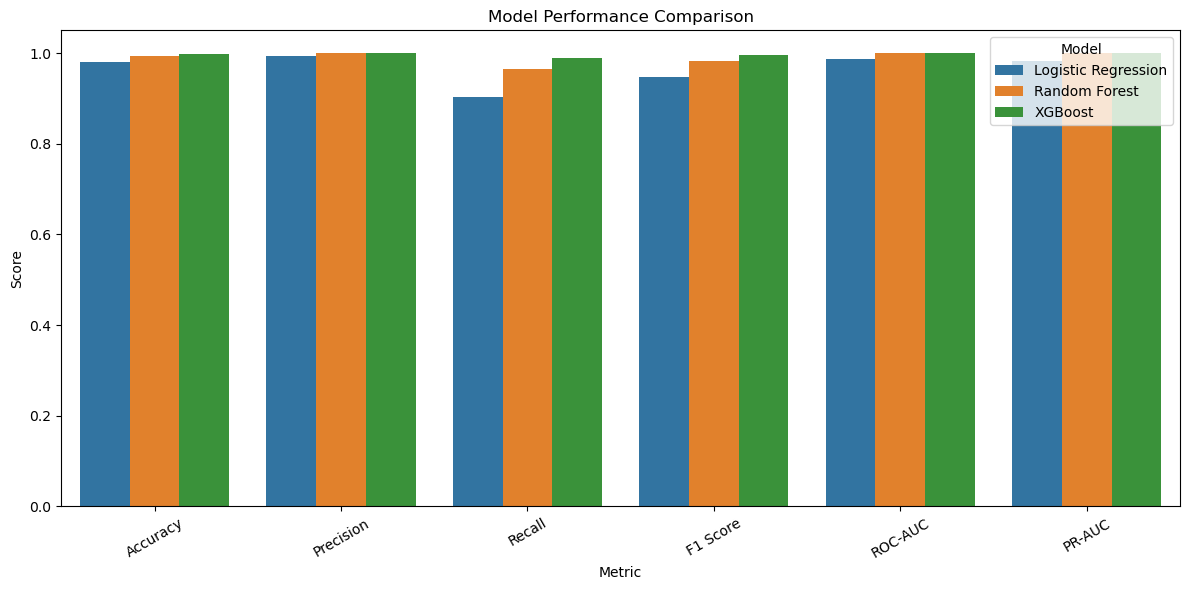

In [57]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC"
]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1.05)
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()